# Assignment 1 Debug

In [ ]:
# import
import sys

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.append("..")

from utils.data import get_dataloaders


In [ ]:
# data loading
mnist = get_dataloaders("mnist", batch_size=64, data_root="../data")
cifar10 = get_dataloaders("cifar10", batch_size=64, data_root="../data")
cifar10_preprocess = get_dataloaders(
    "cifar10",
    batch_size=64,
    data_root="../data",
    use_preprocess=True,
)

for dataset in tqdm([mnist, cifar10, cifar10_preprocess], desc="datasets"):
    images, labels = next(iter(dataset["train_loader"]))
    print(dataset["dataset_name"], "preprocess" if dataset["use_preprocess"] else "")
    print("data root:", dataset["data_root"])
    print("classes:", dataset["num_classes"])
    print("input shape:", dataset["input_shape"])
    print("image batch:", tuple(images.shape))
    print("label batch:", tuple(labels.shape))
    print()


c:\Users\UOS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


datasets:   0%|          | 0/3 [00:00<?, ?it/s]

mnist 
data root: ..\data\mnist
classes: 10
input shape: (1, 28, 28)
image batch: (64, 1, 28, 28)
label batch: (64,)

cifar10 
data root: ..\data\cifar10
classes: 10
input shape: (3, 32, 32)
image batch: (64, 3, 32, 32)
label batch: (64,)

cifar10 preprocess
data root: ..\data\cifar10
classes: 10
input shape: (3, 224, 224)
image batch: (64, 3, 224, 224)
label batch: (64,)



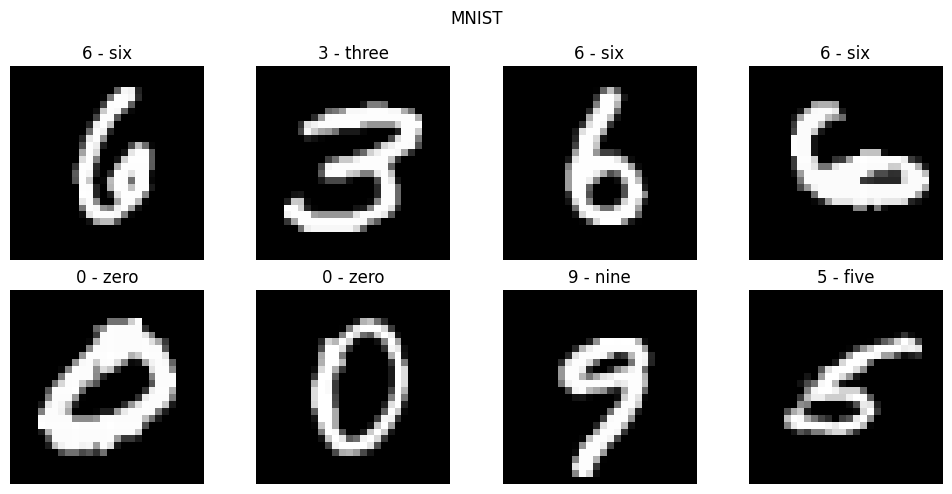

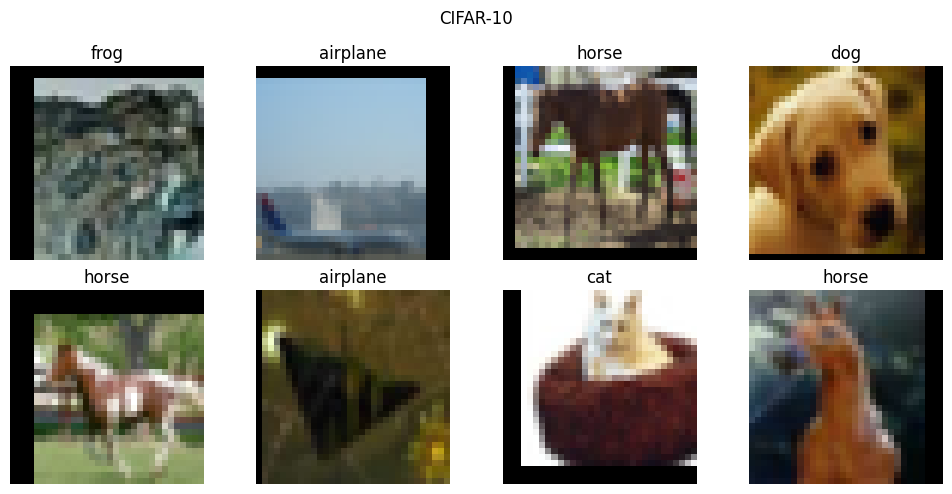

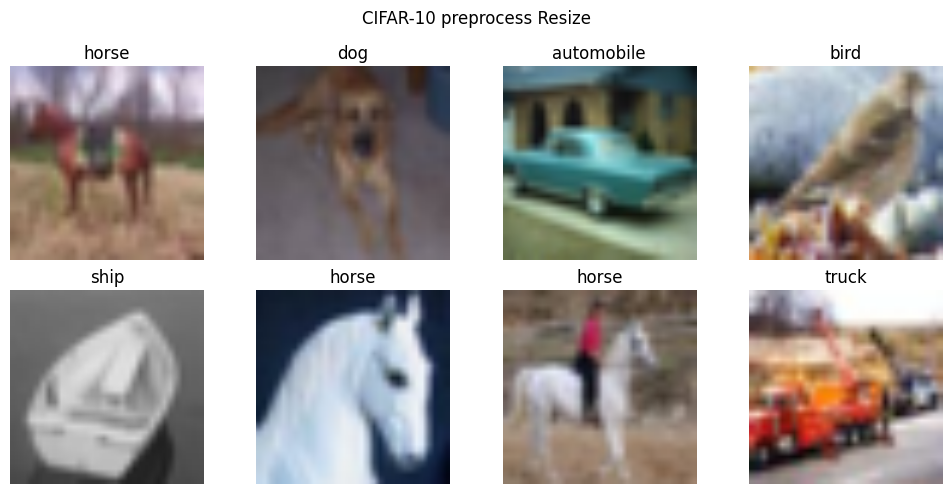

In [ ]:
# visualize
def show_batch(dataset, title):
    images, labels = next(iter(dataset["train_loader"]))
    images = images[:8]
    labels = labels[:8]

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    axes = axes.flatten()

    for ax, image, label in zip(axes, images, labels):
        if image.shape[0] == 1:
            ax.imshow(image.squeeze(0), cmap="gray")
        else:
            ax.imshow(image.permute(1, 2, 0))
        ax.set_title(dataset["class_names"][int(label)])
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(mnist, "MNIST")
show_batch(cifar10, "CIFAR-10")
show_batch(cifar10_preprocess, "CIFAR-10 preprocess Resize")
